# Assignment Instructions - Part 3: Parameter Estimation

This part builds directly on the previous section. Once we know how a model behaves under noise, we can ask a more realistic question: given a noisy dataset, what parameter values are most consistent with the observations?

The big idea is to treat this like a debugging task: test candidate parameters, compare output behavior, and decide which values best explain observed data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

import generate_dataset as gd

sp.init_printing()

## Start Here

We will do this in four small steps:

1. Generate one synthetic dataset with known truth metadata.
2. Run a brute-force search over candidate parameters.
3. Compare estimated parameters against truth.
4. Use the plot and error value to reason about trust in the estimated model.

In [2]:
# Generate one synthetic dataset
data, truth = gd.generate_dataset(
    model_name="exponential",
    seed=420,
    n_points=60,
    noise_fraction=0.10,
 )

display(data.head())
truth

,x,y
0,1.000000,47.936733
1,1.322034,42.233731
2,1.644068,37.003409
3,1.966102,31.454600
4,2.288136,27.297701


{'model_name': 'exponential',
 'parameters': {'A': 79.96840826135686, 'k': 0.47513005448377715},
 'seed': 420,
 'noise_fraction': 0.1,
 'n_points': 60}

In [3]:
#TODO: Copy/Paste the figure generation code from the previous notebook here.

### Parameter Estimation Starter

This is a simple model-fitting workflow:

> define a model --> define an error metric --> search for the parameter pair that minimizes that error.

***TODO:*** Before running the search, discuss in your group which parameter (`P0` or `r`) you think will be harder to recover under noise, and why.

We will keep the mathematical theme consistent with SymPy by writing the model symbolically first and then converting it to a numerical function for the brute-force search. The point is not simply to get a number, but to inspect the error landscape and ask whether the fit makes physical sense.

In [29]:
# 1. Observed data from the synthetic dataset
x_obs = data["x"].to_numpy()
y_obs = data["y"].to_numpy()

# 2. Symbolic model keeps the mathematics readable and in the SymPy theme
P0, r, x_sym = sp.symbols("P0 r x_sym", positive=True)
exp_symbolic = P0 * sp.exp(r * x_sym)
print("Symbolic model:") 
display(exp_symbolic)

# Convert the symbolic expression to a numerical function for the grid search
exp_model = sp.lambdify((x_sym, P0, r), exp_symbolic, "numpy")

# 3. Define the cost function to compare model output to data
#    We use mean squared error (MSE), which is a standard choice for noisy observations.
def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean((y_true - y_pred) ** 2))

# 4. Search a finite grid of candidate parameters
p0_grid = np.linspace(0, 200, 120)
r_grid = np.linspace(0.001, 0.5, 120)

best = {"error": np.inf, "P0": None, "r": None}
for p0_val in p0_grid:
    for r_val in r_grid:
        y_pred = exp_model(x_obs, p0_val, r_val)
        err = mse(y_obs, y_pred)
        if err < best["error"]:
            best = {"error": err, "P0": float(p0_val), "r": float(r_val)}

print("Best fit on this grid:")
print(best)

Symbolic model:


Best fit on this grid:
{'error': 120.18662209932141, 'P0': 6.722689075630252, 'r': 0.001}


## Plot the results and see if the model looks right

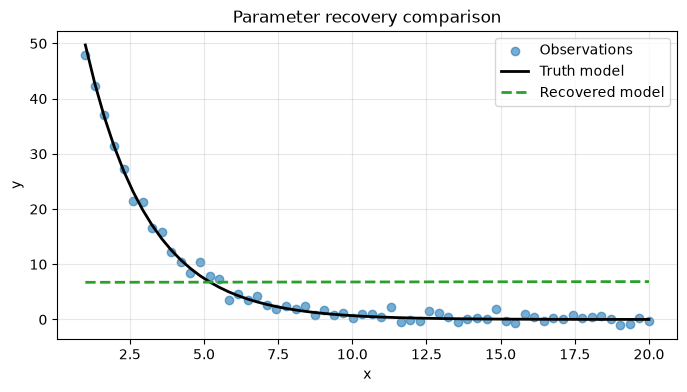

Recovered: {'P0': 6.722689075630252, 'r': 0.001}
Truth parameters: {'A': 79.96840826135686, 'k': 0.47513005448377715}
Best MSE: 120.18662209932141


Model with fitted parameters:


In [30]:
# Compare observations, best-fit model, and truth
best_curve = exp_model(x_obs, best["P0"], best["r"])
truth_curve = gd.evaluate_truth(x_obs, truth)

plt.figure(figsize=(8, 4))
plt.scatter(x_obs, y_obs, alpha=0.6, label="Observations")
plt.plot(x_obs, truth_curve, color="black", lw=2, label="Truth model")
plt.plot(x_obs, best_curve, color="tab:green", lw=2, ls="--", label="Recovered model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Parameter recovery comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Recovered:", {k: v for k, v in best.items() if k != "error"})
print("Truth parameters:", truth["parameters"])
print("Best MSE:", best["error"])

print("\n\nModel with fitted parameters:")
fitted_model = exp_symbolic.subs({
    P0: best['P0'],
    r: best['r'],
})
fitted_model

## Interpretation:

Notice that "best fit" point found is is on the boundary of the search space which suggests we should inspect the search range.

This is a useful debugging signal, not a failure.

- The 'best' parameter pair is the lowest MSE on the chosen search window.
- If the optimum sits at the edge, the true minimum may lie outside the current range.
- This is exactly the kind of result that motivates a wider or shifted search.

### Debugging routine: 3 steps

1. Identify the location of the bug.
   - What part of the workflow is producing the suspicious result?
   - In this example, the likely suspects are the model form and the search range.
2. Identify the reason.
   - Why would this produce the observed behavior?
   - For this dataset, the signal is decaying, so a growth model or a range that stays too close to zero will tend to bias the fit toward the lower boundary.
3. Identify the fix.
   - What is the smallest root-cause correction?
   - In this example, the fix is to use the correct exponential-decay model and check whether the search window actually includes the relevant decay scale.

This section is intentionally a debugging exercise. The synthetic dataset is generated from an exponential decay model, not a growth model:

$$y = P_0 e^{-r x}$$

not

$$y = P_0 e^{r x}$$

If your best-fit `r` value lands at the lower edge of the grid, that is not a success signal. It usually means one of two things: 

- the model form is wrong, or
- the search window does not include the physically relevant range.

For this dataset, `r` should be on the order of a few tenths, not near zero.

***TODO:*** adjust the above code to find the best fit model. What is your lowest error value in the class?

### Discuss and Share

After running the recovery and comparison plot, discuss and be ready to share back:

- Did the estimated parameters match truth closely?
- Which parameter looked more sensitive to noise?
- Could multiple parameter pairs produce similarly good fits?
- What is one debugging step you would add before trusting an estimated model?

# PUT YOUR GROUP ANSWERS HERE

- Matching truth:
- Noise sensitivity notes:
- Multiple-good-fit notes:
- Extra debugging step: